## Introduction

Recently I have been exploring running websites and other services on different compute infrastructures (cloud and local). I have found that some of the less powerful machines struggle to build and run some of my websites/services which cause slow development and bad performance for end users. This is unacceptable if you value speed, uptime and quality. I have experimented with different-sized VM's in the cloud, different computers locally and would like to make this trial‑and‑error process more refined. My goal with this model is to efficiently allocate compute resources for a list of services. 

This problem can be bucketed into a type of bin-packing problem which in short is about solving for the optimal way to pack items into different sized bins. Here we can think of the items as services running on the compute and the bins as the computers. 


I have made some assumptions to simplify this problem:

1. A finite set of compute types (e.g., Raspberry Pi, Orange Pi, PC, Server) with known CPU capacity, memory capacity, power consumption, and cost.
2. A finite set of services, each with static CPU and memory demands known beforehand.
3. Services can only be hosted on a single compute resource.


## Model

Let:

* $T$ be the set of compute types.
* $S$ be the set of services.
* $M \;=\;\{(t,j)\;|\;t\in T,\;j=1,\dots,X\}.$ Where X is a reasonable upper bound

### Parameters

| Symbol    | Description                                     |
| --------- | ----------------------------------------------- |
| $c_t$     | CPU capacity of compute type $t$                 |
| $m_t$     | Memory capacity of compute type $t$ (GB)   |
| $p_t$     | Power consumption of compute type $t$ (W)           |
| $f_t$     | Fixed cost per compute of type $t$ (\$)           |
| $r_s$     | CPU requirement of service $s$                  |
| $d_s$     | Memory requirement of service $s$ (GB)            |
| $\lambda$ | Weighting factor to trade off power consumption ($0 \leq \lambda < \infty$). A greater $\lambda$ places more emphasis on minimizing power usage |
| MAX\_COST | Max cost to pay for machines |


### Decision Variables

* $x_{t,j}\in\{0,1\}$: 1 if you provision the $j$-th machine of type $t$, 0 otherwise.
* $a_{s,t,j}\in\{0,1\}$: 1 if service $s$ is placed on machine $(t,j)$, 0 otherwise.

### Constraints

1. Every service must go on exactly one machine

   $$
     \sum_{(t,j)\in M} a_{s,t,j} \;=\; 1
     \quad\forall\,s\in S.
   $$

2. CPU capacity of each machine must not be exceeded

   $$
     \sum_{s\in S} r_s\,a_{s,t,j}
     \;\le\;
     c_{t}\;x_{t,j}
     \quad\forall\,(t,j)\in M.
   $$

3. Memory capacity of each machine must not be exceeded

   $$
     \sum_{s\in S} d_s\,a_{s,t,j}
     \;\le\;
     m_{t}\;x_{t,j}
     \quad\forall\,(t,j)\in M.
   $$

4. You can’t assign a service to a machine you didn’t spin up

   $$
     a_{s,t,j}\;\le\;x_{t,j}
     \quad\forall\,s\in S,\;(t,j)\in M.
   $$

5. Max cost
   $$
    \sum_{(t,j)\in M} f_t x_{t,j} \leq \text{MAX\_COST}
   $$

   $$
     x_{t,j}\in\{0,1\},\quad a_{s,t,j}\in\{0,1\}.
   $$

### Objective

Minimize the sum of hardware costs plus a weighted penalty for power consumption:

$$
  \min_{x,a}\;
  \sum_{(t,j)\in M}\bigl(f_{t} \;+\;\lambda\,p_{t}\bigr)\;x_{t,j}
$$


## Solution

In [90]:
using JuMP, GLPK, Gurobi, Plots

In [91]:
T = [:RPi5, :RPi4, :OPiZero3, :OPi5B, :MacMiniM4Pro, :PC_i5_12400, :Server_xeonE5_2670]
# CPU performance scores take from the Geekbench 5 benchmark
c = Dict(
    :RPi5           => 2215,   # Raspberry Pi 5 multi-core score https://browser.geekbench.com/v6/cpu/11806459
    :RPi4           => 689,    # Raspberry Pi 4 multi-core score https://browser.geekbench.com/v6/cpu/11800526
    :OPiZero3       => 442,    # Orange Pi Zero 3 multi-core score https://browser.geekbench.com/v6/cpu/2188652
    :OPi5B           => 3102,   # Orange Pi 5B multi-core score https://browser.geekbench.com/v6/cpu/7283540
    :MacMiniM4Pro   => 22539,  # Apple Mac Mini M4 pro multi-core score https://browser.geekbench.com/v6/cpu/11809663
    :PC_i5_12400    => 7089,   # Intel Core i5‑12400 multi-core score https://browser.geekbench.com/v6/cpu/11808280
    :Server_xeonE5_2670 => 30539  # Intel Xeon E5‑2670 multi-core score (inflated to 22539 to best the Mac Mini M4 Pro)
)
# Memory capacity (GB)
m = Dict(
    :RPi5               => 8.0,    # 8 GB variant of Raspberry Pi 5
    :RPi4               => 4.0,    # Raspberry Pi 4 Model B (4 GB)
    :OPiZero3           => 2.0,    # Orange Pi Zero 3 (2 GB) 
    :OPi5B              => 16.0,   # Orange Pi 5B (16 GB)
    :MacMiniM4Pro       => 32.0,   # Apple Mac mini M4 Pro base model (32 GB unified)
    :PC_i5_12400        => 32.0,  # Intel i5‑12400 supports up to 128 GB But 32 GB is normal computers I have access to 
    :Server_xeonE5_2670 => 384.0   # Xeon E5‑2670 supports up to 384 GB
)

# Power consumption at full power (Watts)
p = Dict(
    :RPi5               => 12,
    :RPi4               => 6,
    :OPiZero3           => 1,
    :OPi5B              => 15,
    :MacMiniM4Pro       => 140,
    :PC_i5_12400        => 400,
    :Server_xeonE5_2670 => 750 # https://www.lenovo.com/us/en/p/servers-storage/servers/racks/thinksystem-sr650-v3/len21ts0013?displayrulevalidation=false
)

# Cost per compute (USD)
f = Dict(
    :RPi5               => 100.00,    # 8 GB model
    :RPi4               => 65.00,    # Raspberry Pi 4
    :OPiZero3           => 25.00,   # Orange Pi Zero 3 (2 GB)
    :OPi5B              => 140.00,   # Orange Pi 5B (16 GB)
    :MacMiniM4Pro       => 2900.00,   # Mac mini M4 Pro https://www.apple.com/shop/buy-mac/mac-mini/apple-m4-pro-chip-with-12-core-cpu-16-core-gpu-24gb-memory-512gb
    :PC_i5_12400        => 1450.00,  # Intel i5‑12400 PC
    :Server_xeonE5_2670 => 2868.98   # Xeon E5‑2670 RCP https://www.lenovo.com/us/en/p/servers-storage/servers/racks/thinksystem-sr650-v3/len21ts0013?displayrulevalidation=false
)

# Services
S = [
  :static_site_small, :static_site_large,
  :wordpress_cached,  :wordpress_dynamic,
  :nodejs_blog,       :django_api,
  :gatsby_static,
  :db_small,          :db_large,
  :ml_inference,      :ml_training,
  :video_transcode
]
# CPU requirements (Geekbench points)
r = Dict(
  :static_site_small  => 100,
  :static_site_large  => 200,
  :wordpress_cached   => 300,
  :wordpress_dynamic  => 600,
  :nodejs_blog        => 400,
  :django_api         => 500,
  :gatsby_static      => 150,
  :db_small           => 1000,
  :db_large           => 1500,
  :ml_inference       => 2500,
  :ml_training        => 5000,
  :video_transcode    => 3500
)

# Memory requirements (GB)
d = Dict(
  :static_site_small  => 0.25,
  :static_site_large  => 0.50,
  :wordpress_cached   => 1.00,
  :wordpress_dynamic  => 2.00,
  :nodejs_blog        => 1.00,
  :django_api         => 1.50,
  :gatsby_static      => 0.50,
  :db_small           => 4.00,
  :db_large           => 8.00,
  :ml_inference       => 8.00,
  :ml_training        => 16.00,
  :video_transcode    => 4.00
)
;

In [92]:
# Subset of services to test
S = [
  :static_site_small, :static_site_large, :wordpress_cached, :nodejs_blog, :video_transcode, :db_large, :ml_training
];

In [93]:

# Model
λ = 0.5  # weight for power in the objective
X = 100 # max machines
MAX_COST = 10100

model = Model(Gurobi.Optimizer)

# decision vars
@variable(model, x[t in T, j=1:X], Bin)            # spin up slot j of type t?
@variable(model, a[s in S, t in T, j=1:X], Bin)    # assign service s → (t,j)?

total_cpu_demand = sum(r[s] for s in S)
total_ram_demand = sum(d[s] for s in S)
println("\nTotal CPU demanded by services:  ", total_cpu_demand)
println("Total RAM demanded by services:  ", total_ram_demand)


# each service on exactly one slot
@constraint(model, [s in S], sum(a[s,t,j] for t in T, j in 1:X) == 1)

# capacity constraints per slot
@constraint(model, [t in T, j in 1:X], sum(r[s] * a[s,t,j] for s in S) <= c[t] * x[t,j])
@constraint(model, [t in T, j in 1:X], sum(d[s] * a[s,t,j] for s in S) <= m[t] * x[t,j])

# no assignment to dead slots
@constraint(model, [s in S, t in T, j in 1:X], a[s,t,j] <= x[t,j])

# symmetry‐breaking so slots fill in order
@constraint(model, [t in T, j in 1:X-1], x[t,j] >= x[t,j+1])

# max cost constraint
@constraint(model, sum(f[t] * x[t,j] for t in T, j in 1:X) <= MAX_COST)

# objective: fixed cost + power per spun‐up slot
@objective(model, Min, sum((f[t] + λ*p[t]) * x[t,j] for t in T, j in 1:X))

set_silent(model)
optimize!(model)

total_cpu_provisioned = sum(c[t] * value(x[t,j]) for t in T, j in 1:X)
total_ram_provisioned = sum(m[t] * value(x[t,j]) for t in T, j in 1:X)
println("\nTotal CPU capacity provisioned: ", total_cpu_provisioned)
println("Total RAM capacity provisioned: ", total_ram_provisioned)

total_cost = sum(f[t] * value(x[t,j]) for t in T, j in 1:X)
total_power = sum(p[t] * value(x[t,j]) for t in T, j in 1:X)
println("\nTotal cost of provisioned machines: \$", round(total_cost, digits=2))
println("Total power consumption at full load: ", total_power, " W")


println("\nMachines provisioned:")
for t in T, j in 1:X
    if value(x[t,j]) > 0.5
        println("  $(t), slot $j")
    end
end

println("\nService assignments:")
for s in S, t in T, j in 1:X
    if value(a[s,t,j]) > 0.5
        println("  $s → $(t), slot $j")
    end
end

Set parameter Username
Set parameter LicenseID to value 2649580
Academic license - for non-commercial use only - expires 2026-04-09

Total CPU demanded by services:  11000
Total RAM demanded by services:  30.75

Total CPU capacity provisioned: 22539.0
Total RAM capacity provisioned: 32.0

Total cost of provisioned machines: $2900.0
Total power consumption at full load: 140.0 W

Machines provisioned:
  MacMiniM4Pro, slot 1

Service assignments:
  static_site_small → MacMiniM4Pro, slot 1
  static_site_large → MacMiniM4Pro, slot 1
  wordpress_cached → MacMiniM4Pro, slot 1
  nodejs_blog → MacMiniM4Pro, slot 1
  video_transcode → MacMiniM4Pro, slot 1
  db_large → MacMiniM4Pro, slot 1
  ml_training → MacMiniM4Pro, slot 1


## Results, Discussion, Analysis

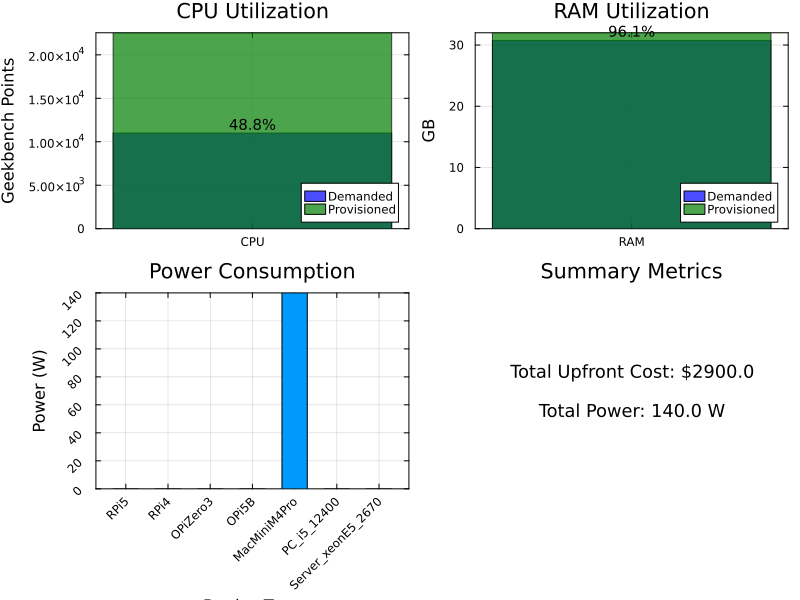

In [94]:
# CPU Utilization Plot
cpu_plot = bar(
    ["CPU"],
    [total_cpu_demand],
    bar_width = 0.4,
    label = "Demanded",
    color = :blue,
    alpha = 0.7,
    legend = :bottomright,
    title = "CPU Utilization",
    ylabel = "Geekbench Points",
    framestyle = :box
)

# Add the provisioned CPU bar
bar!(
    cpu_plot,
    ["CPU"],
    [total_cpu_provisioned],
    bar_width = 0.4,
    label = "Provisioned",
    color = :green,
    alpha = 0.7
)

# Calculate and display utilization percentage
cpu_percent = round(total_cpu_demand / total_cpu_provisioned * 100, digits=1)
annotate!(
    cpu_plot,
    [(0.5, total_cpu_demand + 1000, text("$cpu_percent%", 10, :black))]
)

# RAM Utilization Plot
ram_plot = bar(
    ["RAM"],
    [total_ram_demand],
    bar_width = 0.4,
    label = "Demanded",
    color = :blue,
    alpha = 0.7,
    legend = :bottomright,
    title = "RAM Utilization",
    ylabel = "GB",
    framestyle = :box
)

# Add the provisioned RAM bar
bar!(
    ram_plot,
    ["RAM"],
    [total_ram_provisioned],
    bar_width = 0.4,
    label = "Provisioned",
    color = :green,
    alpha = 0.7
)

# Calculate and display utilization percentage
ram_percent = round(total_ram_demand / total_ram_provisioned * 100, digits=1)
annotate!(
    ram_plot,
    [(0.5, total_ram_demand + 1.5, text("$ram_percent%", 10, :black))]
)

power_by_type = [
    sum(p[t] * value(x[t,j]) for j in 1:X)
    for t in T
]
labels = string.(T)

power_plot = bar(
    labels,
    power_by_type,
    bar_width  = 0.6,
    xlabel     = "Device Type",
    ylabel     = "Power (W)",
    title      = "Power Consumption",
    legend     = false,
    framestyle = :box,
    rotation   = 45,
)

# Create a summary text plot for totals
summary_plot = plot(
    title = "Summary Metrics",
    framestyle = :none,
    grid = false,
    showaxis = false,
    ticks = false,
    legend = false
)
annotate!(
    summary_plot,
    [
        (0.5, 0.6, text("Total Upfront Cost: \$$(round(total_cost, digits=2))", 12, :black, :center)),
        (0.5, 0.4, text("Total Power: $(round(total_power, digits=2)) W", 12, :black, :center))
    ]
)

# Create a plot that contains both subplots
combined_plot = plot(
    cpu_plot, ram_plot, power_plot, summary_plot, 
    layout = (2, 2), 
    size = (800, 600)
)
# Display the plot
display(combined_plot)

This model is able to decide what compute infrastructure to use. It follows my intuitive approach and when I change the service requirements it adjusts and changes its assignments.  

#### Limitations
- This model is very limited to its data scope. If we had a more inclusive list of compute resources it would be a lot easier to optimize it further. For example, when you have an amount of services to run that is inbetween the specs of the given PCs it will use the larger of the two and there is a lot of unused compute. If the model had more options to choose from there would be less of a gap in compute usage because those computers would be more efficient.  

- The thoroughness of the compute params could also be improved. Some services need more specific requirements, think GPU requirement for AI workloads, or networking limits for web access or NAS.  

- This algorithm may also need to be improved as running this program with more machines to choose from may slow it down. 

#### Extensions
This model could be extended to include those extra requirements. We could also add other factors like uptime, physical size, or architecture to make the model more customizable. 

### Conclusion

We have found that optimizing compute resources is a completely feasible task. We are able to optimize for cost, power consumption and resource usage. A possible future direction could be adding more data for each compute resource and service. With the more detailed data we could more efficiently choose hardware to meet our hosting requirements. 